# Now modus operandi here would be:
1. Train test split
2. Scaling the footfall using log_transformer,RP and temparature using standardScaler in the meantime the rest of variable will be encoded with one-hot encoding

# First lets selecting the input and output features first

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
import os
from pathlib import Path

# Detect environment
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)

    # Auto-search for data.csv anywhere inside Google Drive
    print("Searching for data.csv in Google Drive...")
    matches = list(Path("/content/drive/MyDrive").rglob("data.csv"))

    if len(matches) == 0:
        # Last resort: check if already uploaded directly to /content
        if Path("/content/data.csv").exists():
            data_path = Path("/content/data.csv")
            print("Found data.csv in /content")
        else:
            raise FileNotFoundError(
                "data.csv not found anywhere in Google Drive or /content.\n"
                "Please upload data.csv to your Google Drive (any folder) and rerun."
            )
    else:
        data_path = matches[0]
        if len(matches) > 1:
            print(f"Multiple data.csv files found — using: {data_path}")
        else:
            print(f"Found: {data_path}")
else:
    # Local: resolve relative to notebook's own directory
    notebook_dir = Path(os.path.abspath(""))
    data_path = notebook_dir / "data.csv"
    if not data_path.exists():
        data_path = Path(r"C:\Users\Public\My projects\notebook\data.csv")
    if not data_path.exists():
        raise FileNotFoundError(f"data.csv not found. Tried: {data_path}")

print(f"Loading data from: {data_path}")
data = pd.read_csv(data_path)
df = data.copy()
print(f"Data loaded successfully — shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching for data.csv in Google Drive...
Found: /content/drive/MyDrive/data.csv
Loading data from: /content/drive/MyDrive/data.csv
Data loaded successfully — shape: (944, 10)


In [12]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

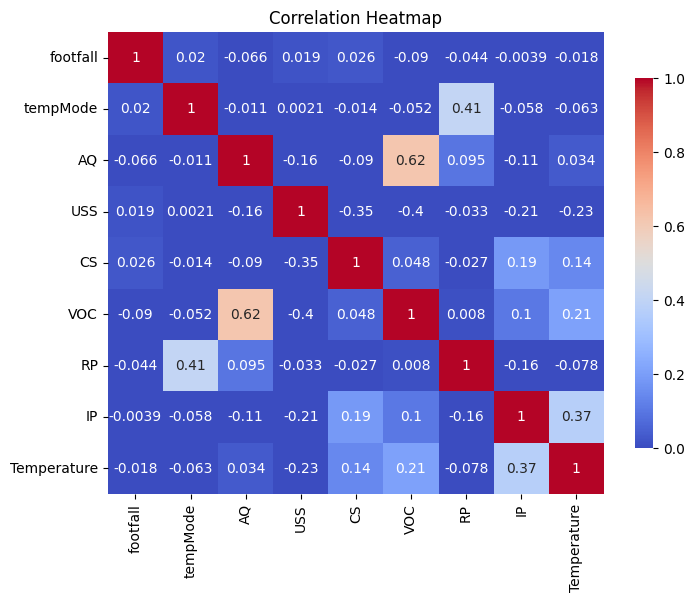

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(
    X.corr(), annot=True, cmap="coolwarm",
            cbar_kws={"shrink": .8},
            vmin=0,
              vmax=1
            )
plt.title("Correlation Heatmap")
plt.savefig("Correlation Heatmap.png")
plt.show()

# Now splitting the data for training and testing

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Now scaling the values and also I will do some encoding

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

log_features = ["footfall"]
standard_features = ["Temperature"]
categorical_features = [col for col in X.columns if col not in log_features + standard_features]

# Transformers
log_transformer = Pipeline(steps=[
    ("log", FunctionTransformer(np.log1p))  # log(1+x) to handle zero values
])

standard_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

ohe_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer combining all
preprocessor = ColumnTransformer(transformers=[
    ("log",      log_transformer,      log_features),
    ("standard", standard_transformer, standard_features),
    ("ohe",      ohe_transformer,      categorical_features)
])

# Fit and transform on training data only, transform test data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print("X_train shape after preprocessing:", X_train_transformed.shape)
print("X_test shape after preprocessing: ", X_test_transformed.shape)


X_train shape after preprocessing: (660, 116)
X_test shape after preprocessing:  (284, 116)


In [16]:
X_train_transformed

array([[ 5.14166356,  0.11968038,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 2.99573227, -0.21501899,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 8.8957666 ,  0.11968038,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 3.17805383,  1.12377849,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 4.7095302 ,  0.11968038,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 4.44265126, -1.55381647,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [17]:
import joblib
import os
save_path = os.path.join(os.getcwd(), "preprocessor.pkl")
joblib.dump(preprocessor, save_path)
print(f"Preprocessor saved to: {save_path}")


Preprocessor saved to: /content/preprocessor.pkl


# Now observing the values againg

In [18]:
# Get output column names from ColumnTransformer
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback for pipelines containing transformers (like FunctionTransformer)
    # that do not expose get_feature_names_out
    ohe_feature_names = (
        preprocessor.named_transformers_["ohe"]
        .named_steps["encoder"]
        .get_feature_names_out(categorical_features)
    )
    feature_names = np.concatenate([log_features, standard_features, ohe_feature_names])

# Convert transformed arrays to DataFrames
X_train_preprocessed_df = pd.DataFrame(
    X_train_transformed, columns=feature_names, index=X_train.index
)
X_test_preprocessed_df = pd.DataFrame(
    X_test_transformed, columns=feature_names, index=X_test.index
)

# View values
print(X_train_preprocessed_df.head())
print(X_test_preprocessed_df.head())

     footfall  Temperature  tempMode_0  tempMode_1  tempMode_2  tempMode_3  \
442  5.141664     0.119680         0.0         1.0         0.0         0.0   
299  2.995732    -0.215019         0.0         0.0         0.0         0.0   
423  8.895767     0.119680         1.0         0.0         0.0         0.0   
294  6.463029    -0.215019         0.0         0.0         1.0         0.0   
133  3.951244    -1.219117         0.0         0.0         1.0         0.0   

     tempMode_4  tempMode_5  tempMode_6  tempMode_7  ...  RP_88  RP_89  RP_91  \
442         0.0         0.0         0.0         0.0  ...    0.0    0.0    0.0   
299         0.0         1.0         0.0         0.0  ...    0.0    0.0    0.0   
423         0.0         0.0         0.0         0.0  ...    0.0    0.0    0.0   
294         0.0         0.0         0.0         0.0  ...    0.0    0.0    0.0   
133         0.0         0.0         0.0         0.0  ...    0.0    0.0    0.0   

     IP_1  IP_2  IP_3  IP_4  IP_5  IP_6  IP_

# Now comes the distance based classifiers training steps/phase

In [19]:
from sklearn.linear_model import (LogisticRegression,LinearRegression, Ridge, Lasso, ElasticNet)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, classification_report,
                             precision_score, recall_score, f1_score)



In [20]:
def evaluate_model(y_true, y_pred):
    print(f"The classification report for the model is:\n{classification_report(y_true, y_pred)}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"The macro Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"The marcro Recall: {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"The macro F1 Score: {f1_score(y_true, y_pred, average='macro'):.4f}")
    print("-" * 50)
    print("Confusion Matrix visualization:")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='cividis',annot_kws={"size": 14, "weight": "bold", "color": "#860A21"})
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    print("=" * 50)

--------------------------------------------------
Evaluating model: LinearRegression
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       160
           1       0.84      0.87      0.86       124

    accuracy                           0.87       284
   macro avg       0.87      0.87      0.87       284
weighted avg       0.87      0.87      0.87       284

Accuracy: 0.8732
The macro Precision: 0.8706
The marcro Recall: 0.8730
The macro F1 Score: 0.8716
--------------------------------------------------
Confusion Matrix visualization:


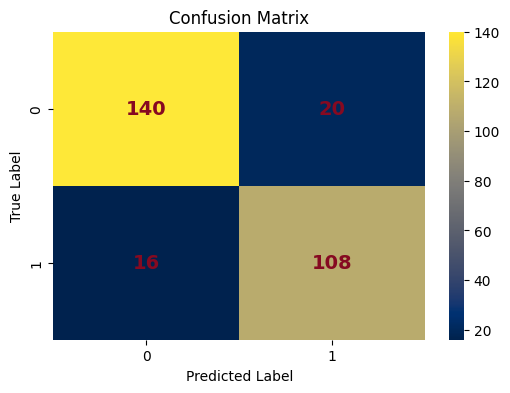

--------------------------------------------------
Evaluating model: Ridge
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       160
           1       0.84      0.87      0.86       124

    accuracy                           0.87       284
   macro avg       0.87      0.87      0.87       284
weighted avg       0.87      0.87      0.87       284

Accuracy: 0.8732
The macro Precision: 0.8706
The marcro Recall: 0.8730
The macro F1 Score: 0.8716
--------------------------------------------------
Confusion Matrix visualization:


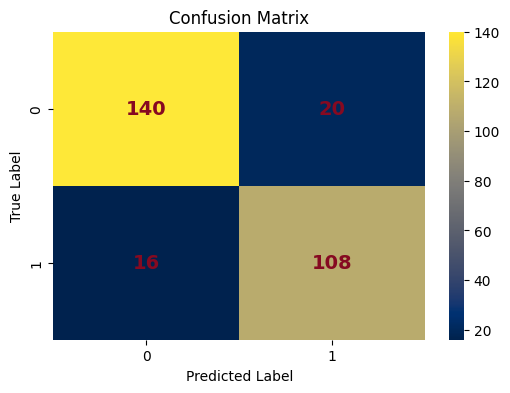

--------------------------------------------------
Evaluating model: Lasso
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72       160
           1       0.00      0.00      0.00       124

    accuracy                           0.56       284
   macro avg       0.28      0.50      0.36       284
weighted avg       0.32      0.56      0.41       284

Accuracy: 0.5634
The macro Precision: 0.2817
The marcro Recall: 0.5000
The macro F1 Score: 0.3604
--------------------------------------------------
Confusion Matrix visualization:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

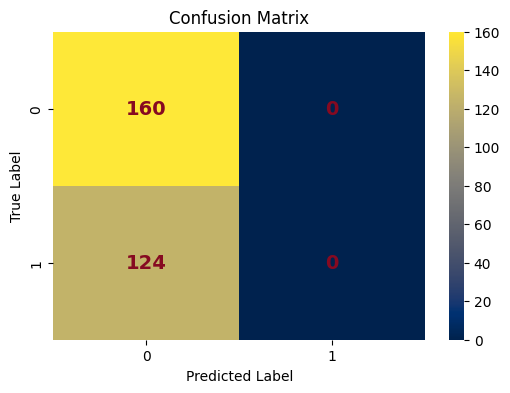

--------------------------------------------------
Evaluating model: ElasticNet
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.75      0.98      0.85       160
           1       0.96      0.57      0.72       124

    accuracy                           0.80       284
   macro avg       0.85      0.78      0.78       284
weighted avg       0.84      0.80      0.79       284

Accuracy: 0.8028
The macro Precision: 0.8535
The marcro Recall: 0.7769
The macro F1 Score: 0.7829
--------------------------------------------------
Confusion Matrix visualization:


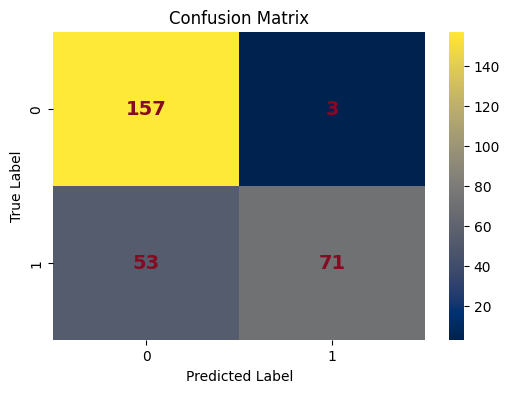

--------------------------------------------------
Evaluating model: LogisticRegression
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       160
           1       0.86      0.87      0.86       124

    accuracy                           0.88       284
   macro avg       0.88      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284

Accuracy: 0.8803
The macro Precision: 0.8779
The marcro Recall: 0.8792
The macro F1 Score: 0.8785
--------------------------------------------------
Confusion Matrix visualization:


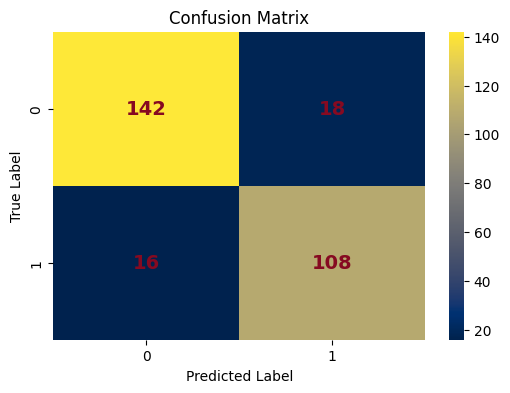

--------------------------------------------------
Evaluating model: SVC
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       160
           1       0.84      0.88      0.86       124

    accuracy                           0.88       284
   macro avg       0.87      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284

Accuracy: 0.8768
The macro Precision: 0.8741
The marcro Recall: 0.8770
The macro F1 Score: 0.8753
--------------------------------------------------
Confusion Matrix visualization:


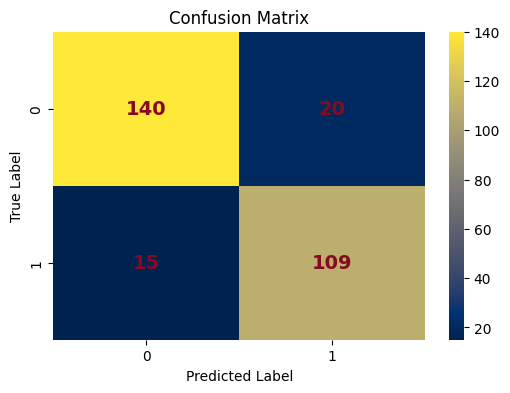

--------------------------------------------------
Evaluating model: KNN
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       160
           1       0.80      0.79      0.79       124

    accuracy                           0.82       284
   macro avg       0.82      0.82      0.82       284
weighted avg       0.82      0.82      0.82       284

Accuracy: 0.8204
The macro Precision: 0.8176
The marcro Recall: 0.8170
The macro F1 Score: 0.8173
--------------------------------------------------
Confusion Matrix visualization:


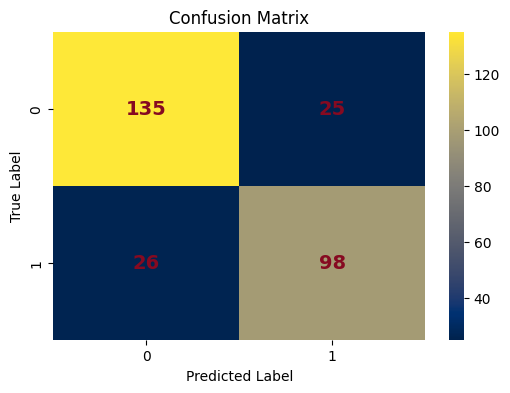

In [21]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "LogisticRegression": LogisticRegression(),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)
    if name in ["LinearRegression", "Ridge", "Lasso", "ElasticNet"]:
        y_pred = (y_pred > 0.5).astype(int)
    print("-"*50)
    print(f"Evaluating model: {name}")
    evaluate_model(y_test, y_pred)

# Out come : here the clear winner is Support vector classifier(runner-up) and Logistic regression(Firs position)

# Now going to apply the tree based models meanwhile ensemble techniques will be applied too

In [22]:
%pip install xgboost catboost

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 1.1 MB/s eta 0:00:00:00:0100:01


--------------------------------------------------
Evaluating model: DecisionTree
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       160
           1       0.83      0.82      0.83       124

    accuracy                           0.85       284
   macro avg       0.85      0.85      0.85       284
weighted avg       0.85      0.85      0.85       284

Accuracy: 0.8486
The macro Precision: 0.8463
The marcro Recall: 0.8457
The macro F1 Score: 0.8460
--------------------------------------------------
Confusion Matrix visualization:


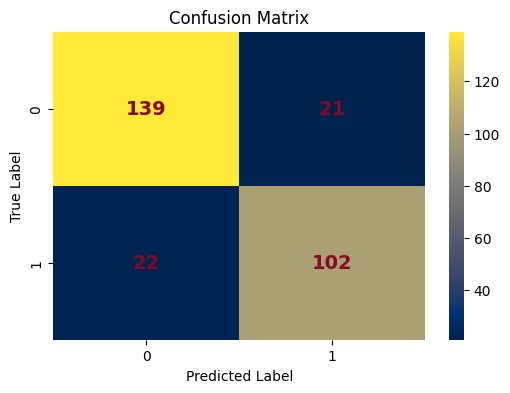

--------------------------------------------------
Evaluating model: RandomForest
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       160
           1       0.87      0.88      0.87       124

    accuracy                           0.89       284
   macro avg       0.89      0.89      0.89       284
weighted avg       0.89      0.89      0.89       284

Accuracy: 0.8873
The macro Precision: 0.8851
The marcro Recall: 0.8864
The macro F1 Score: 0.8857
--------------------------------------------------
Confusion Matrix visualization:


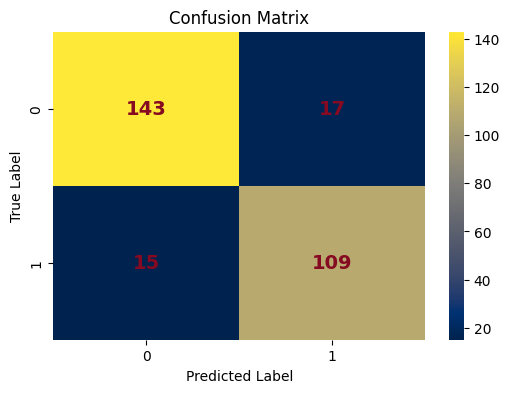

--------------------------------------------------
Evaluating model: GradientBoosting
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       160
           1       0.86      0.87      0.86       124

    accuracy                           0.88       284
   macro avg       0.88      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284

Accuracy: 0.8803
The macro Precision: 0.8779
The marcro Recall: 0.8792
The macro F1 Score: 0.8785
--------------------------------------------------
Confusion Matrix visualization:


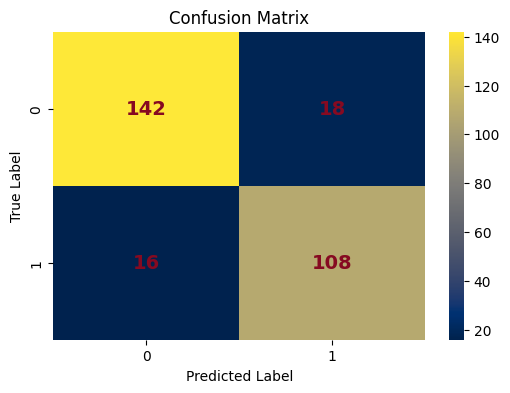

--------------------------------------------------
Evaluating model: XGBoost
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       160
           1       0.83      0.85      0.84       124

    accuracy                           0.86       284
   macro avg       0.86      0.86      0.86       284
weighted avg       0.86      0.86      0.86       284

Accuracy: 0.8592
The macro Precision: 0.8565
The marcro Recall: 0.8578
The macro F1 Score: 0.8571
--------------------------------------------------
Confusion Matrix visualization:


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:55:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


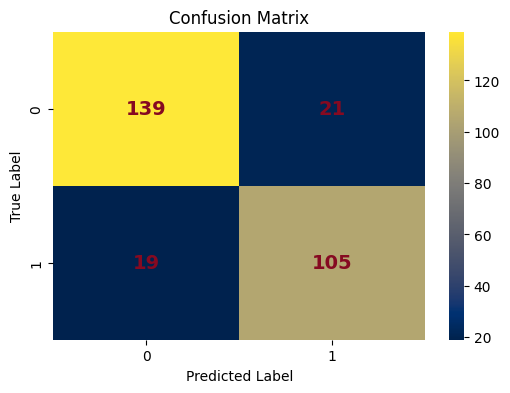

--------------------------------------------------
Evaluating model: CatBoost
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       160
           1       0.85      0.89      0.87       124

    accuracy                           0.88       284
   macro avg       0.88      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284

Accuracy: 0.8838
The macro Precision: 0.8812
The marcro Recall: 0.8842
The macro F1 Score: 0.8824
--------------------------------------------------
Confusion Matrix visualization:


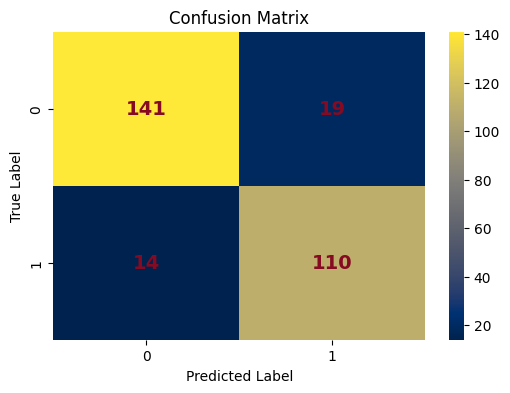

In [23]:
models ={
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "CatBoost": CatBoostClassifier(iterations=100, verbose=0, random_state=42)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("-"*50)
    print(f"Evaluating model: {name}")
    evaluate_model(y_test, y_pred)
    

In [24]:
# IN_COLAB is already set in the data loading cell above
print(f"Running in Colab: {IN_COLAB}")

Running in Colab: True


# Overall decision:
1. Catboost and logisticRegression classifier  is best. So the next plan is:
  

**i. Hyperameter tunning for both this model and than making a hybrid system by combining these two model in votting method**

In [25]:
from catboost.utils import get_gpu_device_count

print("Detected CatBoost GPU devices:", get_gpu_device_count())

Detected CatBoost GPU devices: 0


In [32]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from catboost.utils import get_gpu_device_count

# Detect actual GPU availability (not just Colab)
GPU_AVAILABLE = get_gpu_device_count() > 0
print(f"GPU available: {GPU_AVAILABLE}")

models = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "CatBoostClassifier": CatBoostClassifier(verbose=0, random_state=42)
}

# GridSearchCV requires all values to be lists
catboost_task = {"task_type": ["GPU"], "devices": ["0"]} if GPU_AVAILABLE else {"task_type": ["CPU"]}

params_grid = {
    "LogisticRegression": [
        {
            "C": np.linspace(0.1, 1, 10),
            "penalty": ["l2", None],
            "solver": ["lbfgs", "sag", "newton-cg", "newton-cholesky"],
            "class_weight": ["balanced"]
        },
        {
            "C": np.linspace(0.1, 1, 10),
            "penalty": ["l1", "l2"],
            "solver": ["liblinear"],
            "class_weight": ["balanced"]
        },
        {
            "C": np.linspace(0.1, 1, 10),
            "penalty": ["elasticnet"],
            "solver": ["saga"],
            "l1_ratio": np.linspace(0, 1, 10),
            "class_weight": ["balanced"]
        }
    ],
    "CatBoostClassifier": {
        "iterations": [100, 500],
        "learning_rate": np.linspace(0.01, 0.3, 5),
        "depth": [4, 6, 8],
        "l2_leaf_reg": [1, 10, 50],
        "loss_function": ["Logloss"],
        **catboost_task
    }
}

# LogisticRegression uses scaled/transformed data; CatBoost uses raw data
train_data = {
    "LogisticRegression": X_train_transformed,
    "CatBoostClassifier": X_train
}

best_models = {}
for name, model in models.items():
    print("-"*50)
    print(f"Performing Grid Search for: {name}")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params_grid[name],
        cv=5, n_jobs=-1, verbose=1,
        scoring='recall_macro'
    )
    grid_search.fit(train_data[name], y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")

GPU available: False
--------------------------------------------------
Performing Grid Search for: LogisticRegression
Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters for LogisticRegression: {'C': np.float64(0.6), 'class_weight': 'balanced', 'l1_ratio': np.float64(0.5555555555555556), 'penalty': 'elasticnet', 'solver': 'saga'}
--------------------------------------------------
Performing Grid Search for: CatBoostClassifier
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best parameters for CatBoostClassifier: {'depth': 8, 'iterations': 100, 'l2_leaf_reg': 10, 'learning_rate': np.float64(0.3), 'loss_function': 'Logloss', 'task_type': 'CPU'}


In [31]:
# Randomized Search (faster alternative — tries random subset of combinations)
for name, model in models.items():
    print("-"*50)
    print(f"Performing Randomized Search for: {name}")
    grid_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_grid[name],
        n_iter=20,
        cv=5,
        n_jobs=-1,
        verbose=1,
        scoring='recall_macro',
        random_state=42
    )
    grid_search.fit(train_data[name], y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")

--------------------------------------------------
Performing Randomized Search for: LogisticRegression
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters for LogisticRegression: {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': np.float64(0.5555555555555556), 'class_weight': 'balanced', 'C': np.float64(0.7000000000000001)}
--------------------------------------------------
Performing Randomized Search for: CatBoostClassifier
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for CatBoostClassifier: {'task_type': 'CPU', 'loss_function': 'Logloss', 'learning_rate': np.float64(0.08249999999999999), 'l2_leaf_reg': 50, 'iterations': 500, 'depth': 8}


# Now the test of the models with this parameters

--------------------------------------------------
Evaluating model: LogisticRegressionGridSearch
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       160
           1       0.84      0.90      0.87       124

    accuracy                           0.88       284
   macro avg       0.88      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284

Accuracy: 0.8803
The macro Precision: 0.8779
The marcro Recall: 0.8829
The macro F1 Score: 0.8793
--------------------------------------------------
Confusion Matrix visualization:


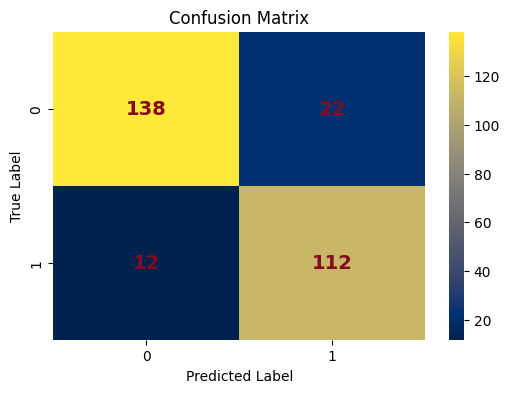

--------------------------------------------------
Evaluating model: CatBoostClassifierGridSearch
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       160
           1       0.86      0.88      0.87       124

    accuracy                           0.88       284
   macro avg       0.88      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284

Accuracy: 0.8838
The macro Precision: 0.8814
The marcro Recall: 0.8833
The macro F1 Score: 0.8822
--------------------------------------------------
Confusion Matrix visualization:


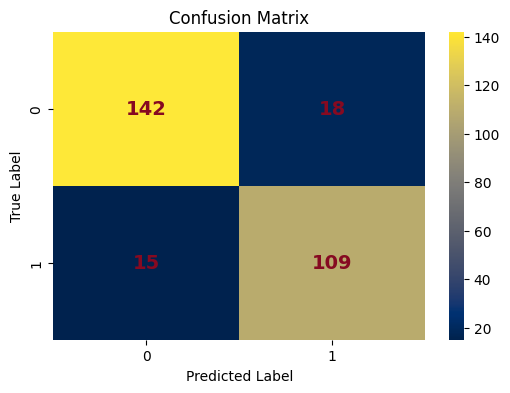

--------------------------------------------------
Evaluating model: LogisticRegressionRandomizedSearch
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       160
           1       0.84      0.90      0.87       124

    accuracy                           0.88       284
   macro avg       0.88      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284

Accuracy: 0.8803
The macro Precision: 0.8779
The marcro Recall: 0.8829
The macro F1 Score: 0.8793
--------------------------------------------------
Confusion Matrix visualization:


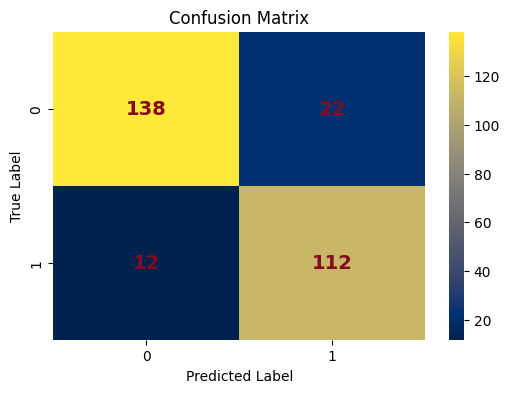

--------------------------------------------------
Evaluating model: CatBoostClassifierRandomizedSearch
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       160
           1       0.85      0.86      0.86       124

    accuracy                           0.87       284
   macro avg       0.87      0.87      0.87       284
weighted avg       0.87      0.87      0.87       284

Accuracy: 0.8732
The macro Precision: 0.8708
The marcro Recall: 0.8721
The macro F1 Score: 0.8714
--------------------------------------------------
Confusion Matrix visualization:


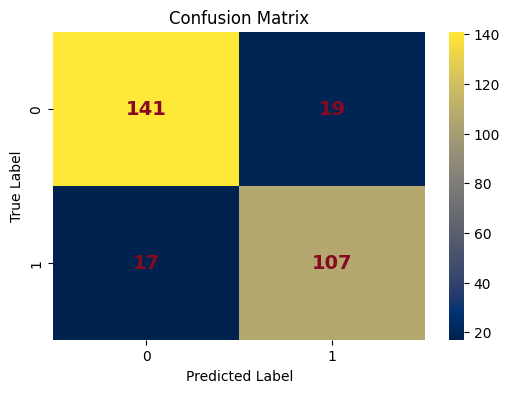

In [40]:
models = {
    "LogisticRegressionGridSearch": LogisticRegression(
        C=0.6, class_weight='balanced', penalty='elasticnet',
        solver='saga', l1_ratio=0.5, max_iter=1000
    ),
    "CatBoostClassifierGridSearch": CatBoostClassifier(
        depth=8, iterations=100, l2_leaf_reg=10, learning_rate=0.3,
        loss_function="Logloss", task_type="CPU", verbose=0
    ),
    "LogisticRegressionRandomizedSearch": LogisticRegression(
        C=0.7, class_weight='balanced', solver="saga",
        penalty="elasticnet", l1_ratio=0.5, max_iter=1000
    ),
    "CatBoostClassifierRandomizedSearch": CatBoostClassifier(
        task_type="CPU", loss_function="Logloss", learning_rate=0.0825,
        l2_leaf_reg=50, iterations=500, depth=8, verbose=0
    )
}

# All 4 models mapped to correct training data
train_data = {
    "LogisticRegressionGridSearch":       X_train_transformed,
    "CatBoostClassifierGridSearch":       X_train,
    "LogisticRegressionRandomizedSearch": X_train_transformed,
    "CatBoostClassifierRandomizedSearch": X_train
}

for name, model in models.items():
    model.fit(train_data[name], y_train)
    y_pred = model.predict(X_test_transformed if name.startswith("LogisticRegression") else X_test)
    print("-"*50)
    print(f"Evaluating model: {name}")
    evaluate_model(y_test, y_pred)

# Combining the best models: Soft Voting Ensemble (LogisticRegression + CatBoost)
**Strategy:**  
- Wrap the best LogisticRegression inside a `Pipeline` (preprocessor → LR) so it can receive raw data  
- Keep CatBoost as-is (it handles raw features natively)  
- Combine both via `VotingClassifier` with `voting='soft'` (averages predicted probabilities)

Soft Voting Ensemble: LogisticRegression + CatBoost
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       160
           1       0.83      0.88      0.85       124

    accuracy                           0.87       284
   macro avg       0.87      0.87      0.87       284
weighted avg       0.87      0.87      0.87       284

Accuracy: 0.8697
The macro Precision: 0.8670
The marcro Recall: 0.8708
The macro F1 Score: 0.8683
--------------------------------------------------
Confusion Matrix visualization:


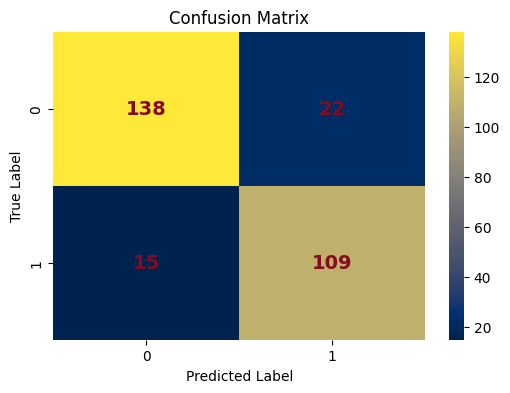

In [42]:
from sklearn.ensemble import VotingClassifier

# Best LR (GridSearch) wrapped in a pipeline so it receives raw X
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("lr", LogisticRegression(
        C=0.6, class_weight='balanced', penalty='elasticnet',
        solver='saga', l1_ratio=0.5, max_iter=1000
    ))
])

# Best CatBoost (GridSearch) — handles raw features natively
catboost_best = CatBoostClassifier(
    depth=8, iterations=100, l2_leaf_reg=10, learning_rate=0.3,
    loss_function="Logloss", task_type="CPU", verbose=0
)

# Soft voting: average predicted probabilities from both models
voting_clf = VotingClassifier(
    estimators=[
        ("lr_pipeline", lr_pipeline),
        ("catboost",    catboost_best)
    ],
    voting="soft"
)

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)

print("=" * 50)
print("Soft Voting Ensemble: LogisticRegression + CatBoost")
evaluate_model(y_test, y_pred_voting)

## Option 1: Weighted Voting
Give CatBoost (the stronger model) 2× the weight of LogisticRegression when averaging probabilities.

Weighted Soft Voting (LR weight=1, CatBoost weight=2)
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       160
           1       0.83      0.88      0.85       124

    accuracy                           0.87       284
   macro avg       0.87      0.87      0.87       284
weighted avg       0.87      0.87      0.87       284

Accuracy: 0.8697
The macro Precision: 0.8670
The marcro Recall: 0.8708
The macro F1 Score: 0.8683
--------------------------------------------------
Confusion Matrix visualization:


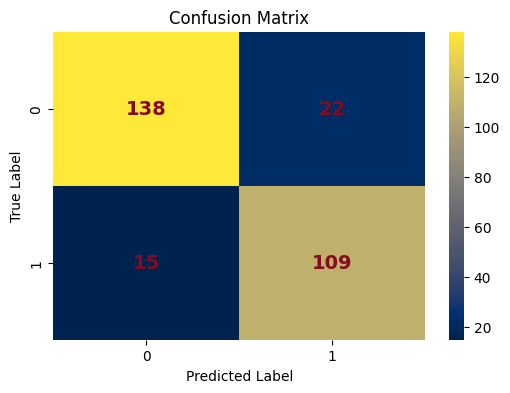

In [45]:
# Weighted soft voting: CatBoost gets 2x the influence of LR
weighted_voting_clf = VotingClassifier(
    estimators=[
        ("lr_pipeline", lr_pipeline),
        ("catboost",    catboost_best)
    ],
    voting="soft",
    weights=[1, 2]   # CatBoost weighted higher
)

weighted_voting_clf.fit(X_train, y_train)
y_pred_weighted = weighted_voting_clf.predict(X_test)

print("=" * 50)
print("Weighted Soft Voting (LR weight=1, CatBoost weight=2)")
evaluate_model(y_test, y_pred_weighted)

## Option 2: Stacking Classifier
LR and CatBoost act as **base learners** — their out-of-fold predictions feed into a **meta-learner** (LogisticRegression) that learns the optimal way to combine them.  
This is more powerful than voting because the meta-learner adapts to each model's strengths.

Stacking Classifier (LR + CatBoost → meta LogisticRegression)
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       160
           1       0.84      0.88      0.86       124

    accuracy                           0.87       284
   macro avg       0.87      0.87      0.87       284
weighted avg       0.87      0.87      0.87       284

Accuracy: 0.8732
The macro Precision: 0.8705
The marcro Recall: 0.8739
The macro F1 Score: 0.8718
--------------------------------------------------
Confusion Matrix visualization:


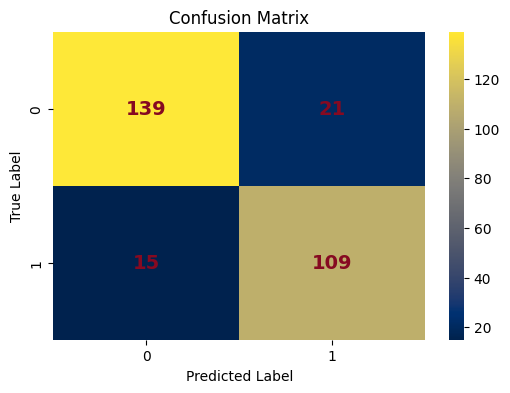

In [46]:
from sklearn.ensemble import StackingClassifier

# Base learners — each receives raw X (LR pipelined with preprocessor)
estimators = [
    ("lr_pipeline", lr_pipeline),
    ("catboost",    catboost_best)
]

# Meta-learner learns how to best combine the two base model outputs
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,                    # 5-fold cross-val to generate out-of-fold predictions
    stack_method="predict_proba",   # feed probabilities to meta-learner
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)

print("=" * 50)
print("Stacking Classifier (LR + CatBoost → meta LogisticRegression)")
evaluate_model(y_test, y_pred_stack)

# Final Model: CatBoostClassifier (GridSearch best params)
Best performer across all experiments — **88.38% accuracy, macro F1 = 0.882**.  
Saving the trained model to disk for use in the prediction pipeline.

Final Model Evaluation — CatBoostClassifier (GridSearch)
The classification report for the model is:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       160
           1       0.86      0.88      0.87       124

    accuracy                           0.88       284
   macro avg       0.88      0.88      0.88       284
weighted avg       0.88      0.88      0.88       284

Accuracy: 0.8838
The macro Precision: 0.8814
The marcro Recall: 0.8833
The macro F1 Score: 0.8822
--------------------------------------------------
Confusion Matrix visualization:


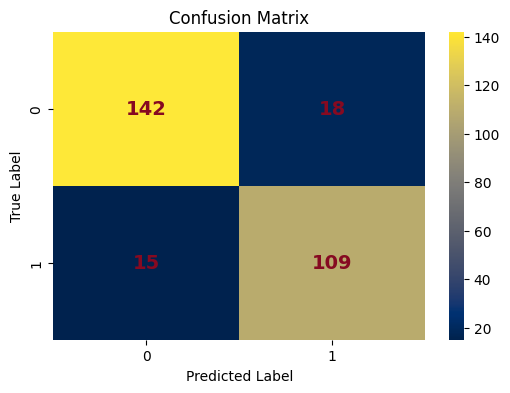

Model saved to: /content/best_model.pkl


In [47]:
import joblib

# Re-instantiate and train the final model on the full training set
final_model = CatBoostClassifier(
    depth=8, iterations=100, l2_leaf_reg=10, learning_rate=0.3,
    loss_function="Logloss", task_type="CPU", verbose=0
)
final_model.fit(X_train, y_train)

# Evaluate one last time
y_pred_final = final_model.predict(X_test)
print("Final Model Evaluation — CatBoostClassifier (GridSearch)")
print("=" * 50)
evaluate_model(y_test, y_pred_final)

# Save model to disk
model_save_path = os.path.join(os.getcwd(), "best_model.pkl")
joblib.dump(final_model, model_save_path)
print(f"Model saved to: {model_save_path}")

In [52]:
import shutil

if IN_COLAB:
    drive_save_dir = Path("/content/drive/MyDrive")
    for fname in ["best_model.pkl", "preprocessor.pkl"]:
        src = Path("/content") / fname
        dst = drive_save_dir / fname
        shutil.copy(src, dst)
        print(f"Copied to Google Drive: {dst}")
    print("\nFind them at: My Drive > best_model.pkl / preprocessor.pkl")
else:
    print("Running locally — files are already at:", os.getcwd())

Copied to Google Drive: /content/drive/MyDrive/best_model.pkl
Copied to Google Drive: /content/drive/MyDrive/preprocessor.pkl

Find them at: My Drive > best_model.pkl / preprocessor.pkl


In [48]:
os.getcwd()

'/content'